### Agglomerative clustering on Retail Data

**Objective:** Discover customr segments using bottom_up hierarchical clustering and visualize with a dendrogram.
**Pipeline:** Load Data -> ED -> Scaling -> Linkage Method -> Agglomerative clustring -> Evaluation

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [6]:
## Load Retail Dataset

df = generate_retail_dataset(n_samples=2000, random_state = RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 11)


,CustomerID,Age,Annual_Income,Spending_Score,Region,Product_Category,Purchase_Channel,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,1,22,107813,32,East,Furniture,In-Store,13,489.18,6663.34,Premium
1,2,58,26206,84,West,Clothing,Online,19,45.83,996.14,Regular
2,3,52,59752,4,East,Sports,In-Store,16,83.28,1471.70,Budget
3,4,40,65826,45,East,Electronics,Online,20,417.10,9209.14,Regular
4,5,40,99787,80,South,Groceries,Online,18,81.11,1467.51,VIP


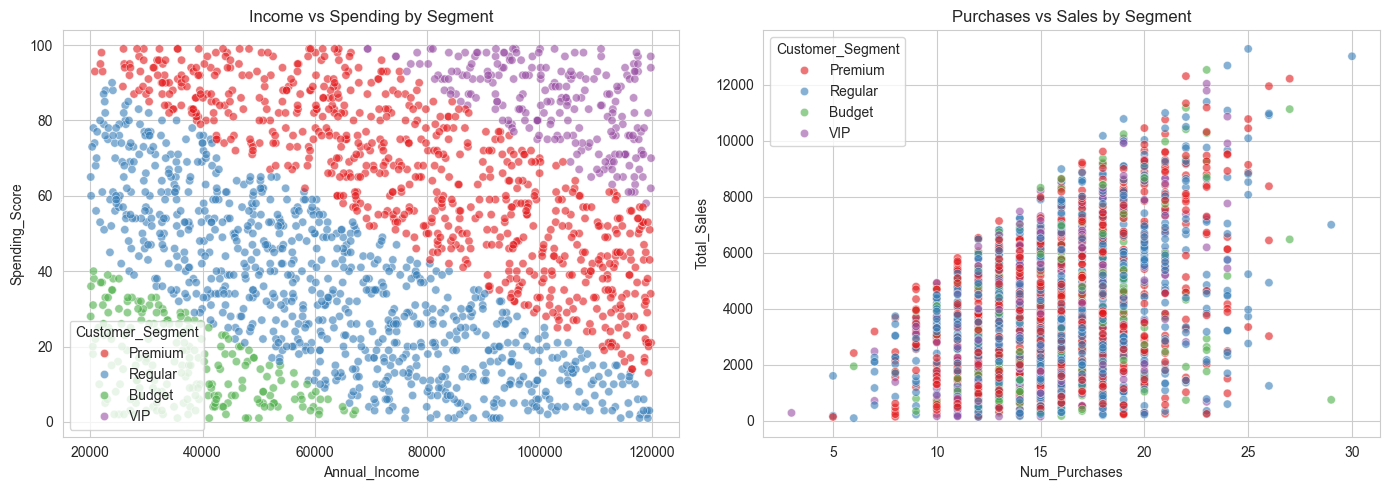

In [15]:
## Exploratory Data Analysis

numerical_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Trancsaction_Value', 'Total_Sales']

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data = df, x= 'Annual_Income', y='Spending_Score', hue='Customer_Segment', ax=axes[0],palette='Set1', alpha=0.6)
axes[0].set_title('Income vs Spending by Segment')
sns.scatterplot(data= df, x= 'Num_Purchases', y='Total_Sales', hue='Customer_Segment', ax=axes[1], palette='Set1', alpha=0.6)
axes[1].set_title('Purchases vs Sales by Segment')
plt.tight_layout()
plt.show()

In [18]:
## Preprocessing

feature_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled data shape: {X_scaled.shape}')

Scaled data shape: (2000, 5)


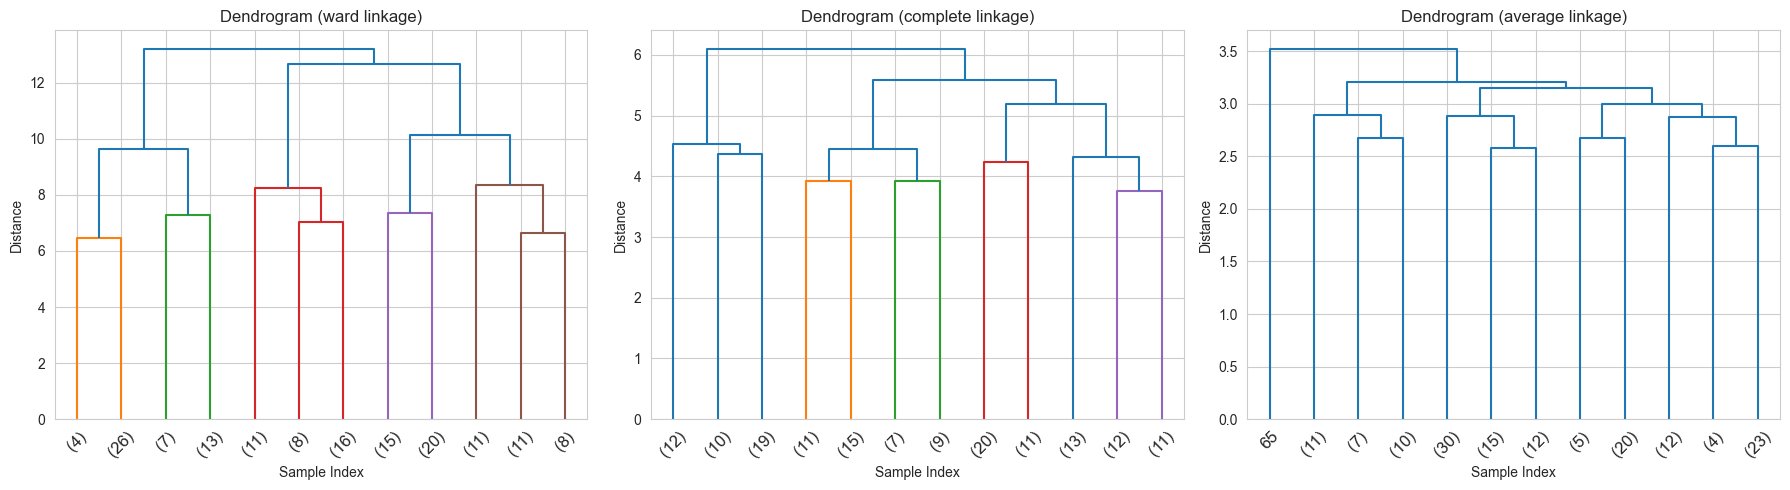

In [26]:
sample_size = 150
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=12, leaf_rotation=45)
    ax.set_title(f'Dendrogram ({method} linkage)')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [ ]:
## Compare Linkage Methods & Optimal K
k_range = range(2, 9)
results = []

for method in ['ward', 'complete', 'average']:
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        results.append({'linkage': method, 'k': k, 'silhouette': sil, 'davies_bouldin': db})

results_df = pd.DataFrame(results)
results_df

,linkage,k,silhouette,davies_bouldin
0,ward,2,0.100745,2.862978
1,ward,3,0.089360,2.381047
2,ward,4,0.082701,2.177664
3,ward,5,0.090357,1.983577
4,ward,6,0.093744,1.893965
5,ward,7,0.089242,1.780085
6,ward,8,0.093704,1.748238
7,complete,2,0.078334,3.192162
8,complete,3,0.053723,3.028619
9,complete,4,0.066222,2.576883


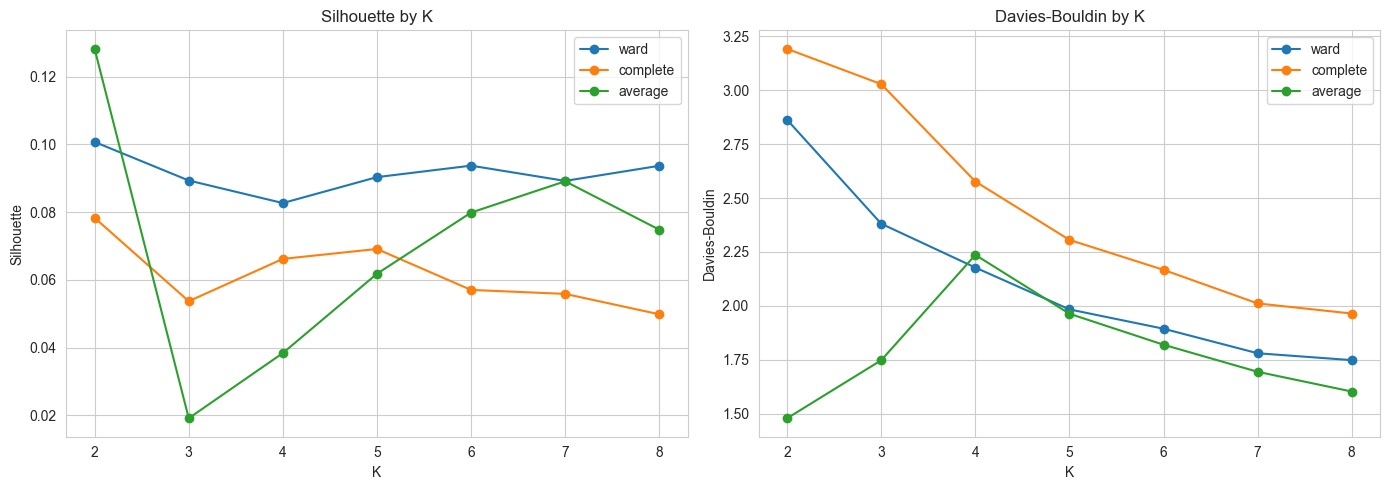

Best config: linkage=average, K=2, silhouette=0.1282


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in ['ward', 'complete', 'average']:
    subset = results_df[results_df['linkage'] == method]
    axes[0].plot(subset['k'], subset['silhouette'], 'o-', label=method)
    axes[1].plot(subset['k'], subset['davies_bouldin'], 'o-', label=method)

axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette'); axes[0].set_title('Silhouette by K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Davies-Bouldin'); axes[1].set_title('Davies-Bouldin by K')
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['silhouette'].idxmax()]
print(f'Best config: linkage={best["linkage"]}, K={int(best["k"])}, silhouette={best["silhouette"]:.4f}')

In [29]:
## Train Final Agglomerative Model

OPTIMAL_K = int(best['k'])
BEST_LINKAGE = best['linkage']

agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=BEST_LINKAGE)
df['Cluster'] = agg.fit_predict(X_scaled)

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'Silhouette: {silhouette_score(X_scaled, df["Cluster"]):.4f}')

Cluster distribution:
Cluster
0    1969
1      31
Name: count, dtype: int64
Silhouette: 0.1282


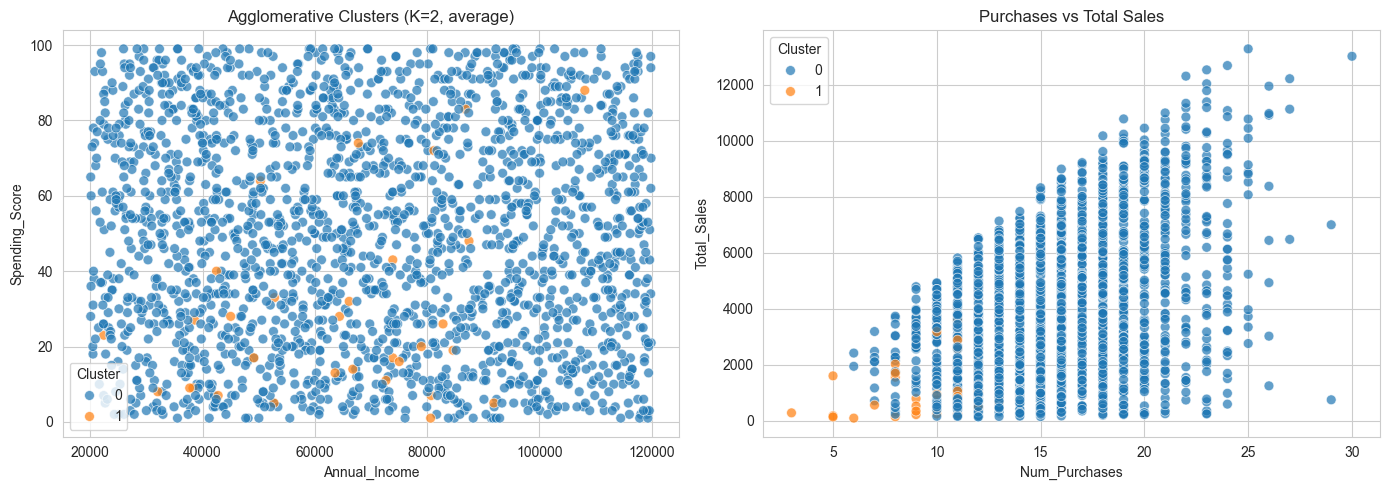

Customer_Segment,Budget,Premium,Regular,VIP
Cluster,,,,
0,0.108,0.363,0.413,0.116
1,0.258,0.129,0.581,0.032


In [34]:
## Visualize Clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='tab10', ax=axes[0], s=50, alpha=0.7)
axes[0].set_title(f'Agglomerative Clusters (K={OPTIMAL_K}, {BEST_LINKAGE})')
sns.scatterplot(data=df, x='Num_Purchases', y='Total_Sales', hue='Cluster', palette='tab10', ax=axes[1], s=50, alpha=0.7)
axes[1].set_title('Purchases vs Total Sales')
plt.tight_layout()
plt.show()

cluster_means = df.groupby('Cluster')[feature_cols + ['Total_Sales']].mean().round(2)
cluster_means

pd.crosstab(df['Cluster'], df['Customer_Segment'], normalize='index').round(3)
